In [1]:
import numpy as np
from emulator.scale_theta import scale_thetas,unscale_thetas
from emulator.sigma_model_no_log.model_prob import Emulator21cm,run_inference
import torch
CHECKPOINT_DEFAULT = "emulator/sigma_model_no_log/checkpoints/emulator.pt"

In [2]:
def load_emulator():
    model = Emulator21cm(n_params=6, n_redshifts=3)
    model.load_state_dict(torch.load(CHECKPOINT_DEFAULT, map_location="cpu"))
    return model
model   = load_emulator()
checkpoint_dir = "emulator/sigma_model_no_log/checkpoints"
scalers = np.load(f"{checkpoint_dir}/scalers.npz")

In [3]:
checkpoint_dir = "emulator/sigma_model_no_log/checkpoints"
split       = torch.load(f"{checkpoint_dir}/dataset_split.pt")
test_thetas = split["test_thetas"]
test_ps2d   = split["test_ps2d"]
theta_obs     = test_thetas[2].numpy()
y_obs         = test_ps2d[2].numpy().flatten()

In [4]:
split['train_ps2d']

tensor([[[[0.0274, 0.0437, 0.0517,  ..., 0.2344, 0.3407, 0.4912],
          [0.0277, 0.0457, 0.0513,  ..., 0.2255, 0.3387, 0.4935],
          [0.0264, 0.0462, 0.0517,  ..., 0.2242, 0.3416, 0.4918],
          ...,
          [0.0273, 0.0443, 0.0507,  ..., 0.2335, 0.3438, 0.4870],
          [0.0276, 0.0438, 0.0502,  ..., 0.2277, 0.3451, 0.4903],
          [0.0287, 0.0442, 0.0515,  ..., 0.2288, 0.3430, 0.4985]],

         [[0.0224, 0.0356, 0.0420,  ..., 0.1397, 0.2011, 0.2795],
          [0.0201, 0.0371, 0.0395,  ..., 0.1408, 0.2020, 0.2822],
          [0.0188, 0.0365, 0.0397,  ..., 0.1411, 0.1977, 0.2806],
          ...,
          [0.0193, 0.0366, 0.0425,  ..., 0.1393, 0.2032, 0.2821],
          [0.0191, 0.0377, 0.0418,  ..., 0.1387, 0.2028, 0.2795],
          [0.0194, 0.0350, 0.0432,  ..., 0.1383, 0.2028, 0.2870]],

         [[0.0152, 0.0304, 0.0325,  ..., 0.0930, 0.1248, 0.1755],
          [0.0160, 0.0303, 0.0342,  ..., 0.0921, 0.1246, 0.1727],
          [0.0161, 0.0305, 0.0343,  ..., 0

In [5]:
split['train_xhi']

tensor([[0.9967, 0.9999, 1.0000],
        [0.2849, 0.3703, 0.4487],
        [0.2412, 0.3797, 0.5419],
        ...,
        [0.1679, 0.2227, 0.2776],
        [0.0262, 0.0524, 0.0960],
        [0.0709, 0.1203, 0.1819]])

In [6]:
split

{'train_thetas': tensor([[0.4550, 0.5198, 0.9240, 0.7555, 0.6955, 0.0593],
         [0.2262, 0.5314, 0.2638, 0.2351, 0.2985, 0.3946],
         [0.4666, 0.5704, 0.5268, 0.5956, 0.6420, 0.3394],
         ...,
         [0.6536, 0.4660, 0.3400, 0.1503, 0.1195, 0.4589],
         [0.8342, 0.6348, 0.2147, 0.8720, 0.8695, 0.8885],
         [0.8149, 0.3180, 0.6797, 0.2078, 0.9629, 0.0804]]),
 'train_ps2d': tensor([[[[0.0274, 0.0437, 0.0517,  ..., 0.2344, 0.3407, 0.4912],
           [0.0277, 0.0457, 0.0513,  ..., 0.2255, 0.3387, 0.4935],
           [0.0264, 0.0462, 0.0517,  ..., 0.2242, 0.3416, 0.4918],
           ...,
           [0.0273, 0.0443, 0.0507,  ..., 0.2335, 0.3438, 0.4870],
           [0.0276, 0.0438, 0.0502,  ..., 0.2277, 0.3451, 0.4903],
           [0.0287, 0.0442, 0.0515,  ..., 0.2288, 0.3430, 0.4985]],
 
          [[0.0224, 0.0356, 0.0420,  ..., 0.1397, 0.2011, 0.2795],
           [0.0201, 0.0371, 0.0395,  ..., 0.1408, 0.2020, 0.2822],
           [0.0188, 0.0365, 0.0397,  ..., 0.1

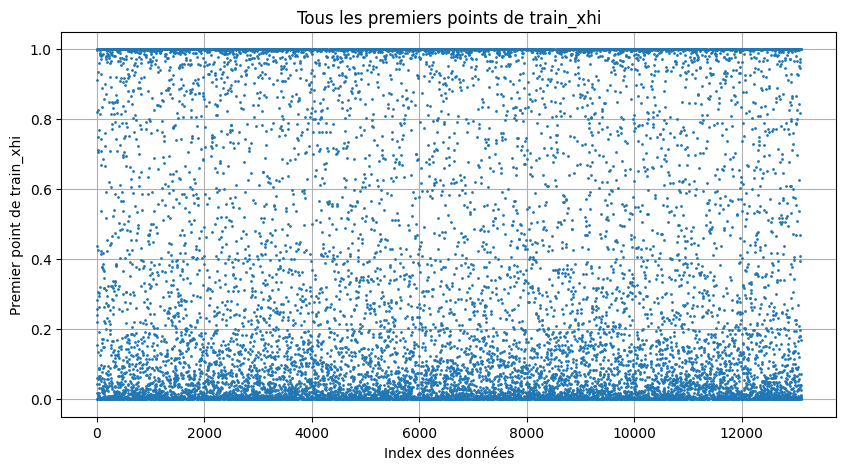

In [7]:
import matplotlib.pyplot as plt

train_xhi = split['train_xhi']

# Récupérer le premier point de chaque ligne
first_points = train_xhi[:, 0]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(first_points.numpy(), '.', markersize=2)

plt.xlabel("Index des données")
plt.ylabel("Premier point de train_xhi")
plt.title("Tous les premiers points de train_xhi")
plt.grid(True)
plt.show()

In [9]:
targets_extra = torch.linspace(
    0.99362564,
    1.0,
    12
)[1:-1]  # 10 points, sans les extrémités
selected_indices = []
used = set()
values = split['train_xhi'][:, 0]

for target in targets_extra:
    distances = torch.abs(values - target)
    order = torch.argsort(distances)

    # Sélectionner l'indice le plus proche non utilisé
    for idx in order.tolist():
        if idx not in used:
            selected_indices.append(idx)
            used.add(idx)
            break

# Afficher les résultats triés par valeur croissante
selected_indices = sorted(
    selected_indices,
    key=lambda idx: values[idx].item()
)

for idx in selected_indices:
    print(f"Index: {idx:5d} | Valeur: {values[idx].item():.4f}")

Index: 11217 | Valeur: 0.9942
Index: 11122 | Valeur: 0.9948
Index:  7759 | Valeur: 0.9954
Index:  6115 | Valeur: 0.9959
Index:  5664 | Valeur: 0.9965
Index:  3383 | Valeur: 0.9971
Index: 12138 | Valeur: 0.9977
Index: 11505 | Valeur: 0.9983
Index:  1682 | Valeur: 0.9988
Index:  8973 | Valeur: 0.9994


In [8]:
import torch

values = split['train_xhi'][:, 0]

# 20 valeurs cibles uniformément espacées
targets = torch.linspace(
    values.min(),
    values.max(),
    20
)

selected_indices = []
used = set()

for target in targets:
    distances = torch.abs(values - target)
    order = torch.argsort(distances)

    # Sélectionner l'indice le plus proche non utilisé
    for idx in order.tolist():
        if idx not in used:
            selected_indices.append(idx)
            used.add(idx)
            break

# Afficher les résultats triés par valeur croissante
selected_indices = sorted(
    selected_indices,
    key=lambda idx: values[idx].item()
)

for idx in selected_indices:
    print(f"Index: {idx:5d} | Valeur: {values[idx].item():.4f}")

Index: 12606 | Valeur: 0.0000
Index: 12112 | Valeur: 0.0527
Index: 10880 | Valeur: 0.1053
Index: 11574 | Valeur: 0.1580
Index:  3213 | Valeur: 0.2107
Index:  5033 | Valeur: 0.2631
Index:   402 | Valeur: 0.3161
Index: 10759 | Valeur: 0.3684
Index:  2316 | Valeur: 0.4208
Index:  7945 | Valeur: 0.4734
Index: 12734 | Valeur: 0.5263
Index:  1661 | Valeur: 0.5782
Index:  4193 | Valeur: 0.6316
Index:  7154 | Valeur: 0.6842
Index: 10066 | Valeur: 0.7367
Index:  6910 | Valeur: 0.7895
Index:  1133 | Valeur: 0.8420
Index:  2218 | Valeur: 0.8948
Index:  3457 | Valeur: 0.9474
Index:  7185 | Valeur: 1.0000


In [10]:
# Récupérer les theta associés aux indices sélectionnés
selected_theta = split['train_thetas'][selected_indices]

for idx, theta in zip(selected_indices, selected_theta):
    print(f"Index: {idx:5d} | Valeur xhi: {values[idx].item():.4f} | Theta: {theta}")

Index: 11217 | Valeur xhi: 0.9942 | Theta: tensor([0.8566, 0.9020, 0.5945, 0.6267, 0.5826, 0.5633])
Index: 11122 | Valeur xhi: 0.9948 | Theta: tensor([0.0944, 0.3028, 0.9569, 0.1250, 0.1953, 0.7977])
Index:  7759 | Valeur xhi: 0.9954 | Theta: tensor([0.3816, 0.2593, 0.9735, 0.7579, 0.2624, 0.5770])
Index:  6115 | Valeur xhi: 0.9959 | Theta: tensor([0.4234, 0.8754, 0.6997, 0.6330, 0.8960, 0.1316])
Index:  5664 | Valeur xhi: 0.9965 | Theta: tensor([0.2928, 0.7381, 0.9852, 0.5261, 0.8150, 0.4484])
Index:  3383 | Valeur xhi: 0.9971 | Theta: tensor([0.2438, 0.6422, 0.3448, 0.3328, 0.0564, 0.8394])
Index: 12138 | Valeur xhi: 0.9977 | Theta: tensor([0.3476, 0.4933, 0.7758, 0.4574, 0.2654, 0.7568])
Index: 11505 | Valeur xhi: 0.9983 | Theta: tensor([0.2933, 0.8730, 0.5235, 0.4055, 0.6172, 0.0492])
Index:  1682 | Valeur xhi: 0.9988 | Theta: tensor([0.2194, 0.4110, 0.6164, 0.4998, 0.0650, 0.8937])
Index:  8973 | Valeur xhi: 0.9994 | Theta: tensor([0.8095, 0.9492, 0.6718, 0.2168, 0.7695, 0.9466])


In [11]:
theta_names = [
    'ALPHA_STAR',
    'F_STAR10',
    'F_ESC10',
    'ALPHA_ESC',
    'M_TURN',
    't_STAR'
]
train_thetas_unscaled = unscale_thetas(split['train_thetas'])

# Liste des theta au format dictionnaire
theta_list = [
    {
        name: value.item()
        for name, value in zip(theta_names, train_thetas_unscaled[idx])
    }
    for idx in selected_indices
]

# Affichage
for i, (idx, theta) in enumerate(zip(selected_indices, theta_list)):
    print(f"--- Theta {i+1} (Index {idx}) ---")
    print(theta)

--- Theta 1 (Index 11217) ---
{'ALPHA_STAR': 0.7848386466503143, 'F_STAR10': -0.2941187024116516, 'F_ESC10': -0.6221356391906738, 'ALPHA_ESC': -0.0599956214427948, 'M_TURN': 9.165189146995544, 't_STAR': 0.563270092010498}
--- Theta 2 (Index 11122) ---
{'ALPHA_STAR': -0.3584030903875828, 'F_STAR10': -2.0916645526885986, 'F_ESC10': 0.8276569843292236, 'ALPHA_ESC': -0.8124654665589333, 'M_TURN': 8.390595257282257, 't_STAR': 0.7976666688919067}
--- Theta 3 (Index 7759) ---
{'ALPHA_STAR': 0.07237674295902252, 'F_STAR10': -2.2220695316791534, 'F_ESC10': 0.894028902053833, 'ALPHA_ESC': 0.13691696524620056, 'M_TURN': 8.524739503860474, 't_STAR': 0.576983630657196}
--- Theta 4 (Index 6115) ---
{'ALPHA_STAR': 0.13506023585796356, 'F_STAR10': -0.37388724088668823, 'F_ESC10': -0.2010030746459961, 'ALPHA_ESC': -0.050447046756744385, 'M_TURN': 9.791935920715332, 't_STAR': 0.131602481007576}
--- Theta 5 (Index 5664) ---
{'ALPHA_STAR': -0.06082944571971893, 'F_STAR10': -0.7855866551399231, 'F_ESC10': 

In [13]:
theta_list

[{'ALPHA_STAR': 0.7848386466503143,
  'F_STAR10': -0.2941187024116516,
  'F_ESC10': -0.6221356391906738,
  'ALPHA_ESC': -0.0599956214427948,
  'M_TURN': 9.165189146995544,
  't_STAR': 0.563270092010498},
 {'ALPHA_STAR': -0.3584030903875828,
  'F_STAR10': -2.0916645526885986,
  'F_ESC10': 0.8276569843292236,
  'ALPHA_ESC': -0.8124654665589333,
  'M_TURN': 8.390595257282257,
  't_STAR': 0.7976666688919067},
 {'ALPHA_STAR': 0.07237674295902252,
  'F_STAR10': -2.2220695316791534,
  'F_ESC10': 0.894028902053833,
  'ALPHA_ESC': 0.13691696524620056,
  'M_TURN': 8.524739503860474,
  't_STAR': 0.576983630657196},
 {'ALPHA_STAR': 0.13506023585796356,
  'F_STAR10': -0.37388724088668823,
  'F_ESC10': -0.2010030746459961,
  'ALPHA_ESC': -0.050447046756744385,
  'M_TURN': 9.791935920715332,
  't_STAR': 0.131602481007576},
 {'ALPHA_STAR': -0.06082944571971893,
  'F_STAR10': -0.7855866551399231,
  'F_ESC10': 0.9407730102539062,
  'ALPHA_ESC': -0.2108379602432251,
  'M_TURN': 9.63008725643158,
  't_STA

In [17]:
try_theta_list = [{'ALPHA_STAR': 0.1802714467048645,
  'F_STAR10': 0.04821549728512764,
  'F_ESC10': 0.0060515450313687325,
  'ALPHA_ESC': 0.4533219337463379,
  'M_TURN': 0.9909403324127197,
  't_STAR': 0.40721940994262695},
 {'ALPHA_STAR': 0.5554603934288025,
  'F_STAR10': 0.2839742600917816,
  'F_ESC10': 0.6318613290786743,
  'ALPHA_ESC': 0.5439430475234985,
  'M_TURN': 0.8735289573669434,
  't_STAR': 0.977533221244812},
 {'ALPHA_STAR': 0.40386438369750977,
  'F_STAR10': 0.07657209038734436,
  'F_ESC10': 0.9209741353988647,
  'ALPHA_ESC': 0.1269567459821701,
  'M_TURN': 0.4683135151863098,
  't_STAR': 0.45396000146865845},
 {'ALPHA_STAR': 0.4163226783275604,
  'F_STAR10': 0.3559200167655945,
  'F_ESC10': 0.8895600438117981,
  'ALPHA_ESC': 0.28399088978767395,
  'M_TURN': 0.9623957276344299,
  't_STAR': 0.7403619289398193},
 {'ALPHA_STAR': 0.18149670958518982,
  'F_STAR10': 0.46705639362335205,
  'F_ESC10': 0.2881125509738922,
  'ALPHA_ESC': 0.20814307034015656,
  'M_TURN': 0.3724503219127655,
  't_STAR': 0.6820170879364014},
 {'ALPHA_STAR': 0.7540853023529053,
  'F_STAR10': 0.8271237015724182,
  'F_ESC10': 0.24379204213619232,
  'ALPHA_ESC': 0.38907089829444885,
  'M_TURN': 0.08499670773744583,
  't_STAR': 0.4279533326625824},
 {'ALPHA_STAR': 0.5891826748847961,
  'F_STAR10': 0.9218645691871643,
  'F_ESC10': 0.2153586894273758,
  'ALPHA_ESC': 0.3639221787452698,
  'M_TURN': 0.41895073652267456,
  't_STAR': 0.9769750237464905},
 {'ALPHA_STAR': 0.39229097962379456,
  'F_STAR10': 0.655982255935669,
  'F_ESC10': 0.451466828584671,
  'ALPHA_ESC': 0.9035837650299072,
  'M_TURN': 0.09655500203371048,
  't_STAR': 0.9369998574256897},
 {'ALPHA_STAR': 0.9485594034194946,
  'F_STAR10': 0.30160918831825256,
  'F_ESC10': 0.8563100695610046,
  'ALPHA_ESC': 0.37833407521247864,
  'M_TURN': 0.20779098570346832,
  't_STAR': 0.4194920063018799},
 {'ALPHA_STAR': 0.7755188345909119,
  'F_STAR10': 0.9992690682411194,
  'F_ESC10': 0.1471625715494156,
  'ALPHA_ESC': 0.04109155386686325,
  'M_TURN': 0.3431907892227173,
  't_STAR': 0.8687956929206848},
 {'ALPHA_STAR': 0.10500841587781906,
  'F_STAR10': 0.7329727411270142,
  'F_ESC10': 0.25344106554985046,
  'ALPHA_ESC': 0.22977706789970398,
  'M_TURN': 0.48208895325660706,
  't_STAR': 0.07908251881599426},
 {'ALPHA_STAR': 0.24136967957019806,
  'F_STAR10': 0.6779907941818237,
  'F_ESC10': 0.25418582558631897,
  'ALPHA_ESC': 0.40172868967056274,
  'M_TURN': 0.12643839418888092,
  't_STAR': 0.644848644733429},
 {'ALPHA_STAR': 0.32592564821243286,
  'F_STAR10': 0.8544117212295532,
  'F_ESC10': 0.36356374621391296,
  'ALPHA_ESC': 0.04532618075609207,
  'M_TURN': 0.718739926815033,
  't_STAR': 0.029710978269577026},
 {'ALPHA_STAR': 0.9474427103996277,
  'F_STAR10': 0.3929867446422577,
  'F_ESC10': 0.9370219707489014,
  'ALPHA_ESC': 0.9731138944625854,
  'M_TURN': 0.0834043025970459,
  't_STAR': 0.966505765914917},
 {'ALPHA_STAR': 0.9203038215637207,
  'F_STAR10': 0.6189092397689819,
  'F_ESC10': 0.6005539298057556,
  'ALPHA_ESC': 0.736327588558197,
  'M_TURN': 0.3441978991031647,
  't_STAR': 0.34226125478744507},
 {'ALPHA_STAR': 0.7152233123779297,
  'F_STAR10': 0.48484930396080017,
  'F_ESC10': 0.9873775839805603,
  'ALPHA_ESC': 0.5997015237808228,
  'M_TURN': 0.5792566537857056,
  't_STAR': 0.03714054077863693},
 {'ALPHA_STAR': 0.8717969059944153,
  'F_STAR10': 0.4507138729095459,
  'F_ESC10': 0.7768658995628357,
  'ALPHA_ESC': 0.5606107115745544,
  'M_TURN': 0.09098467230796814,
  't_STAR': 0.8144731521606445},
 {'ALPHA_STAR': 0.4530261754989624,
  'F_STAR10': 0.6620970368385315,
  'F_ESC10': 0.9660266041755676,
  'ALPHA_ESC': 0.6580730080604553,
  'M_TURN': 0.9378408193588257,
  't_STAR': 0.7374985814094543},
 {'ALPHA_STAR': 0.6955813765525818,
  'F_STAR10': 0.9033203721046448,
  'F_ESC10': 0.5072513818740845,
  'ALPHA_ESC': 0.8480824828147888,
  'M_TURN': 0.5353860259056091,
  't_STAR': 0.47761327028274536},
 {'ALPHA_STAR': 0.42232128977775574,
  'F_STAR10': 0.9084625244140625,
  'F_ESC10': 0.8184848427772522,
  'ALPHA_ESC': 0.029911618679761887,
  'M_TURN': 0.6809578537940979,
  't_STAR': 0.5001048445701599}]

In [19]:
len(try_theta_list)

20